Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Graphs saved to project root.

DATA ANALYSIS REPORT (COPY THIS)
Total Samples: 200

--- 1. CATEGORY BREAKDOWN ---
                count      mean    median       std
Category                                           
Broken (R->W)       1  0.031091  0.031091       NaN
Fixed (W->R)       13 -0.013469 -0.006358  0.037070
Right -> Right    169 -0.006046 -0.002540  0.029349
Wrong -> Wrong     17 -0.009377 -0.005744  0.021999

--- 2. OVERCONFIDENCE TRAPS ---
Count: 1 (0.5% of total)
Avg Confidence Gain in Traps: -0.0651

--- 3. SFT-RL CORRELATION ---
Pearson Correlation: 0.2758

--- 4. REPRESENTATIVE EXAMPLES ---

[Category: Wrong -> Wrong]
  Example 1:
    Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
    Gold: 59
    SFT Answer: 0... (Ent: 0.098)
    RL  Answer: 18... (Ent: 0.033)
    >> Delta: -0.065
  Example 2:
    Q: Each bird eats 12 beetles per day, each snake eats 3 birds per day, a

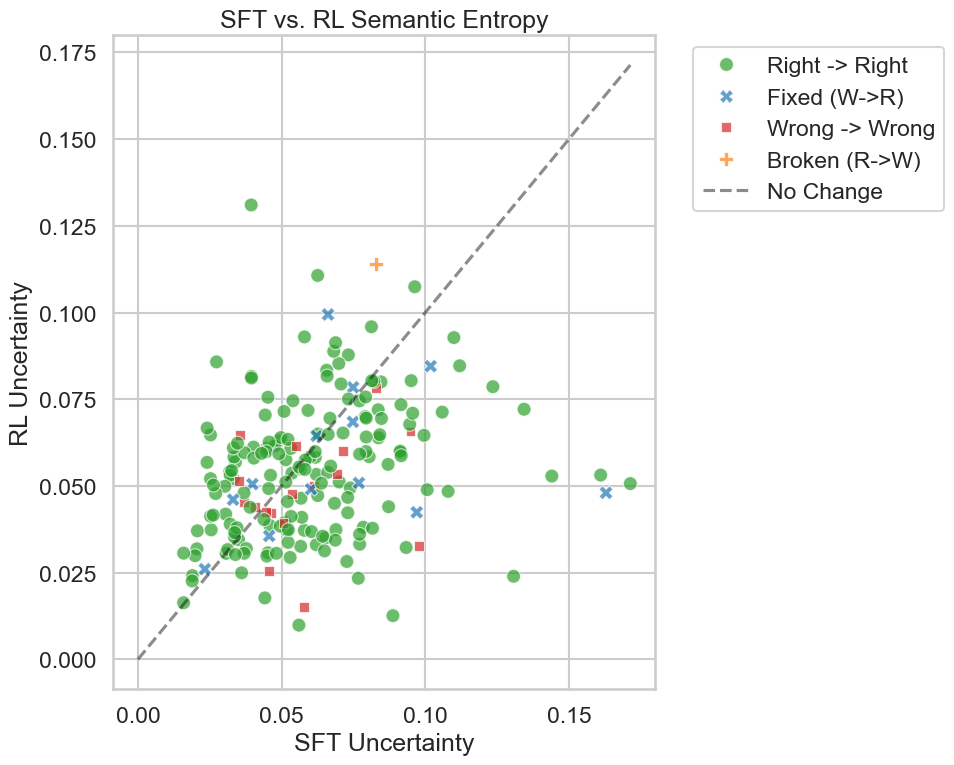

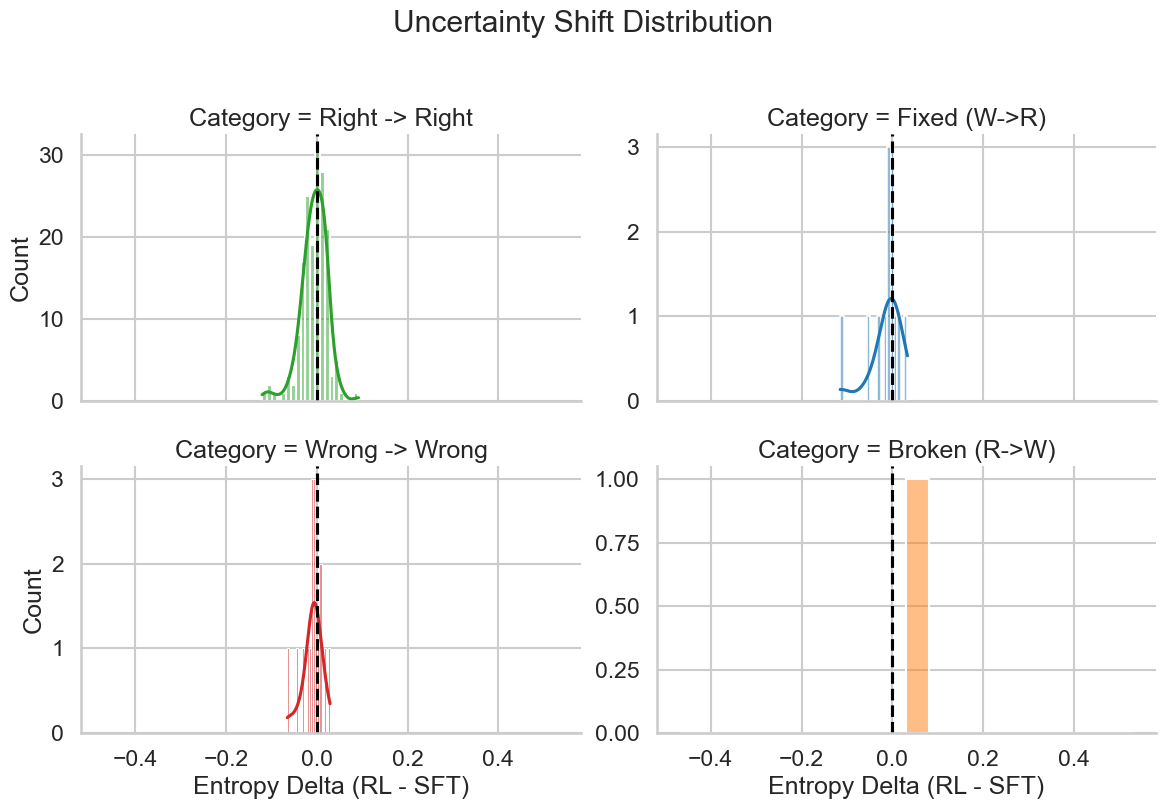

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        exp_name = exp.iloc[0]['experiment_name']
        print(f"Analyzing Experiment: {exp_name} (ID: {exp_id})")

        # Fetch paired results
        # FIXED: Added r.gold_answer to the SELECT list
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer, 
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_entropy_shift():
    df_raw = get_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data: SFT vs RL
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Merge (Inner Join)
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Categorize Outcomes
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    # --- PLOT 1: SCATTER ---
    plt.figure(figsize=(10, 8))
    palette = {
        'Wrong -> Wrong': '#d62728',  # Red
        'Right -> Right': '#2ca02c',  # Green
        'Fixed (W->R)':   '#1f77b4',  # Blue
        'Broken (R->W)':  '#ff7f0e'   # Orange
    }
    sns.scatterplot(
        data=df, x='uq_avg_entropy_SFT', y='uq_avg_entropy_RL', 
        hue='Category', style='Category', palette=palette, s=100, alpha=0.7
    )
    limit = max(df['uq_avg_entropy_SFT'].max(), df['uq_avg_entropy_RL'].max())
    plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label='No Change')
    plt.title("SFT vs. RL Semantic Entropy")
    plt.xlabel("SFT Uncertainty")
    plt.ylabel("RL Uncertainty")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.savefig('scatter_entropy.png')

    # --- PLOT 2: HISTOGRAMS ---
    g = sns.FacetGrid(df, col="Category", col_wrap=2, hue="Category", 
                      palette=palette, sharex=True, sharey=False, height=4, aspect=1.5)
    g.map(sns.histplot, "Entropy_Delta", kde=True, bins=20)
    g.refline(x=0, linestyle="--", color="black")
    g.set_axis_labels("Entropy Delta (RL - SFT)", "Count")
    g.fig.suptitle("Uncertainty Shift Distribution", y=1.02)
    plt.tight_layout()
    plt.savefig('hist_entropy_delta.png')
    
    print("Graphs saved to project root.")

    # --- TEXT ANALYSIS OUTPUT ---
    print("\n" + "="*50)
    print("DATA ANALYSIS REPORT (COPY THIS)")
    print("="*50)
    
    print(f"Total Samples: {len(df)}")
    
    # 1. Category Summary
    print("\n--- 1. CATEGORY BREAKDOWN ---")
    summary = df.groupby('Category')['Entropy_Delta'].agg(['count', 'mean', 'median', 'std'])
    print(summary.to_string())

    # 2. Trap Analysis
    traps = df[(df['is_correct_RL'] == 0) & (df['Entropy_Delta'] < -0.05)]
    print(f"\n--- 2. OVERCONFIDENCE TRAPS ---")
    print(f"Count: {len(traps)} ({len(traps)/len(df)*100:.1f}% of total)")
    if not traps.empty:
        print(f"Avg Confidence Gain in Traps: {traps['Entropy_Delta'].mean():.4f}")

    # 3. Correlation
    corr = df['uq_avg_entropy_SFT'].corr(df['uq_avg_entropy_RL'])
    print(f"\n--- 3. SFT-RL CORRELATION ---")
    print(f"Pearson Correlation: {corr:.4f}")

    # 4. Detailed Examples
    print("\n--- 4. REPRESENTATIVE EXAMPLES ---")
    df['abs_change'] = df['Entropy_Delta'].abs()
    
    for cat in choices:
        subset = df[df['Category'] == cat]
        if subset.empty: continue
        
        examples = subset.sort_values('abs_change', ascending=False).head(2)
        
        print(f"\n[Category: {cat}]")
        for i, (_, row) in enumerate(examples.iterrows()):
            print(f"  Example {i+1}:")
            print(f"    Q: {row['question_text_SFT'][:80]}...")
            # Note: gold_answer_SFT and gold_answer_RL will be identical, so we can use SFT
            print(f"    Gold: {row['gold_answer_SFT']}")
            print(f"    SFT Answer: {str(row['predicted_answer_SFT'])[:]} (Ent: {row['uq_avg_entropy_SFT']:.3f})")
            print(f"    RL  Answer: {str(row['predicted_answer_RL'])[:]} (Ent: {row['uq_avg_entropy_RL']:.3f})")
            print(f"    >> Delta: {row['Entropy_Delta']:.3f}")

    print("="*50)

if __name__ == "__main__":
    analyze_entropy_shift()

Analyzing Experiment ID: 4
Loaded 200 paired samples.
Saved scatter_entropy.png
Saved hist_entropy_delta.png

FORENSIC EXAMPLES

Category: Wrong -> Wrong
Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
SFT Answer (0.098): 0
RL  Answer (0.033): 18
Change: -0.065
--------------------------------------------------------------------------------

Category: Right -> Right
Q: Irene earns $500 if she works for 40 hours a week and gets an extra $20 for ever...
SFT Answer (0.171): 700
RL  Answer (0.051): 700
Change: -0.121
--------------------------------------------------------------------------------

Category: Fixed (W->R)
Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days....
SFT Answer (0.163): 13
RL  Answer (0.048): 6
Change: -0.115
--------------------------------------------------------------------------------

Category: Broken (R->W)
Q: Dan owns an ice cream shop and every sixth customer gets a free ice cream cone. .

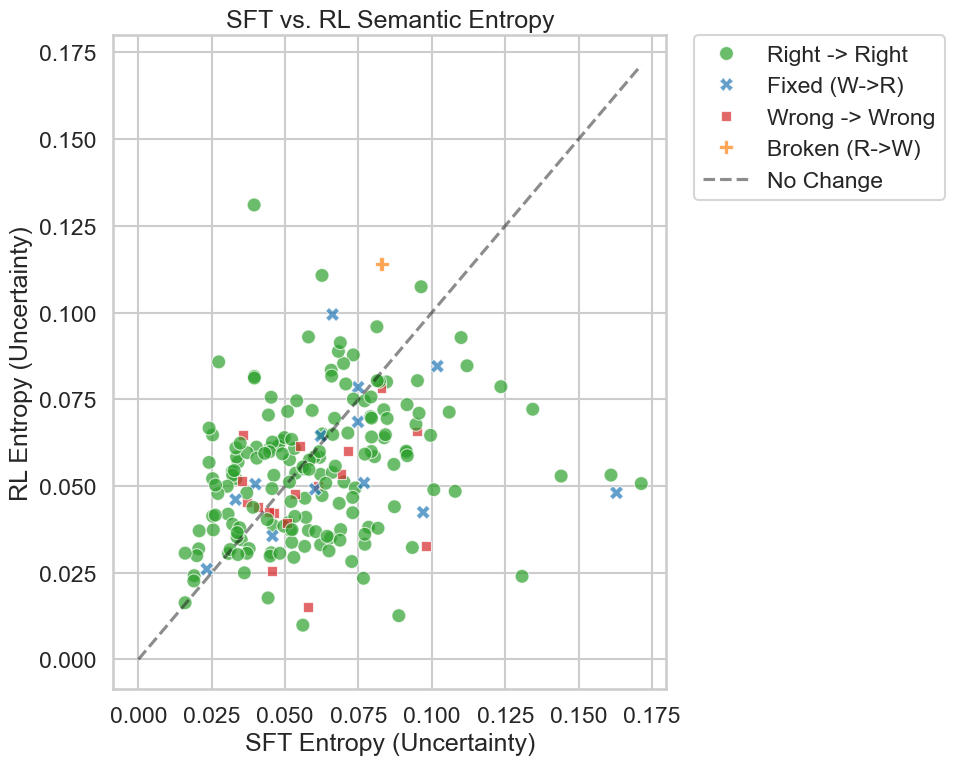

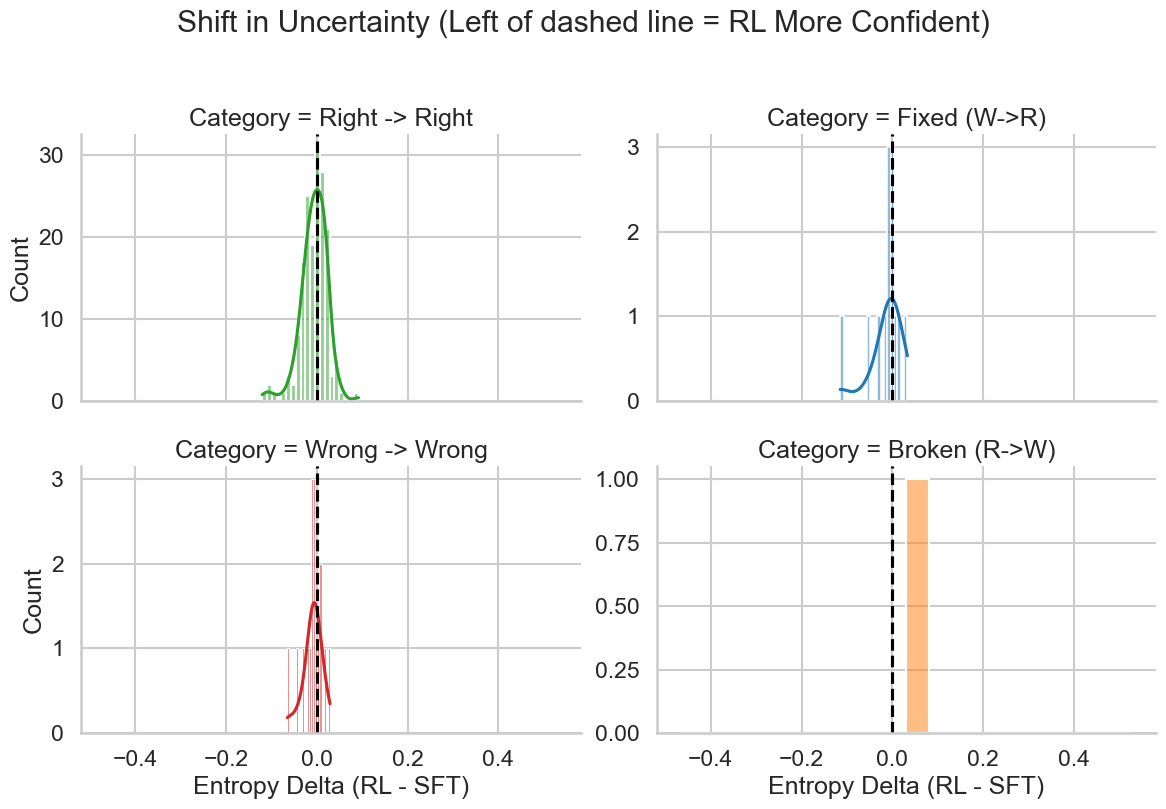

In [5]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment ID: {exp_id}")

        # Fetch paired results
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_scatter_hist():
    df_raw = get_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Define Categories
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta (Negative = RL More Confident)
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    print(f"Loaded {len(df)} paired samples.")

    # --- PLOT 1: SCATTER PLOT ---
    plt.figure(figsize=(10, 8))
    
    # Create custom palette
    palette = {
        'Wrong -> Wrong': '#d62728',  # Red
        'Right -> Right': '#2ca02c',  # Green
        'Fixed (W->R)':   '#1f77b4',  # Blue
        'Broken (R->W)':  '#ff7f0e'   # Orange
    }
    
    sns.scatterplot(
        data=df, x='uq_avg_entropy_SFT', y='uq_avg_entropy_RL', 
        hue='Category', style='Category', palette=palette,
        s=100, alpha=0.7
    )
    
    # Add diagonal "No Change" line
    limit = max(df['uq_avg_entropy_SFT'].max(), df['uq_avg_entropy_RL'].max())
    plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label='No Change')
    
    plt.title("SFT vs. RL Semantic Entropy")
    plt.xlabel("SFT Entropy (Uncertainty)")
    plt.ylabel("RL Entropy (Uncertainty)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.savefig('scatter_entropy.png')
    print("Saved scatter_entropy.png")

    # --- PLOT 2: FACETED HISTOGRAMS ---
    g = sns.FacetGrid(df, col="Category", col_wrap=2, hue="Category", 
                      palette=palette, sharex=True, sharey=False, 
                      height=4, aspect=1.5)
    
    g.map(sns.histplot, "Entropy_Delta", kde=True, bins=20)
    
    # Add reference line at 0
    g.refline(x=0, linestyle="--", color="black")
    
    g.set_axis_labels("Entropy Delta (RL - SFT)", "Count")
    g.fig.suptitle("Shift in Uncertainty (Left of dashed line = RL More Confident)", y=1.02)
    plt.tight_layout()
    plt.savefig('hist_entropy_delta.png')
    print("Saved hist_entropy_delta.png")

    # --- PRINT EXAMPLES ---
    print("\n" + "="*80)
    print("FORENSIC EXAMPLES")
    print("="*80)
    
    # Sort by magnitude of change to find interesting cases
    df_sorted = df.reindex(df['Entropy_Delta'].abs().sort_values(ascending=False).index)
    
    for cat in choices:
        subset = df_sorted[df_sorted['Category'] == cat]
        if subset.empty: continue
        
        # Take the top example
        ex = subset.iloc[0]
        
        print(f"\nCategory: {cat}")
        print(f"Q: {ex['question_text_SFT'][:80]}...")
        print(f"SFT Answer ({ex['uq_avg_entropy_SFT']:.3f}): {str(ex['predicted_answer_SFT'])[:50]}")
        print(f"RL  Answer ({ex['uq_avg_entropy_RL']:.3f}): {str(ex['predicted_answer_RL'])[:50]}")
        print(f"Change: {ex['Entropy_Delta']:.3f}")
        print("-" * 80)

if __name__ == "__main__":
    analyze_scatter_hist()

Analyzing Experiment ID: 4
Data Loaded: 200 paired questions.
Category
Right -> Right    169
Wrong -> Wrong     17
Fixed (W->R)       13
Broken (R->W)       1
Name: count, dtype: int64
Saved: sft_rl_entropy_violin.png
Saved: sft_rl_entropy_delta.png

REPRESENTATIVE EXAMPLES

Category: Wrong -> Wrong
Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
SFT (0.098): 0
RL  (0.033): 18
------------------------------------------------------------

Category: Right -> Right
Q: Irene earns $500 if she works for 40 hours a week and gets an extra $20 for every hour of overtime. ...
SFT (0.171): 700
RL  (0.051): 700
------------------------------------------------------------

Category: Fixed (W->R)
Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days. How long will he ri...
SFT (0.163): 13
RL  (0.048): 6
------------------------------------------------------------

Category: Broken (R->W)
Q: Dan owns an ice cream

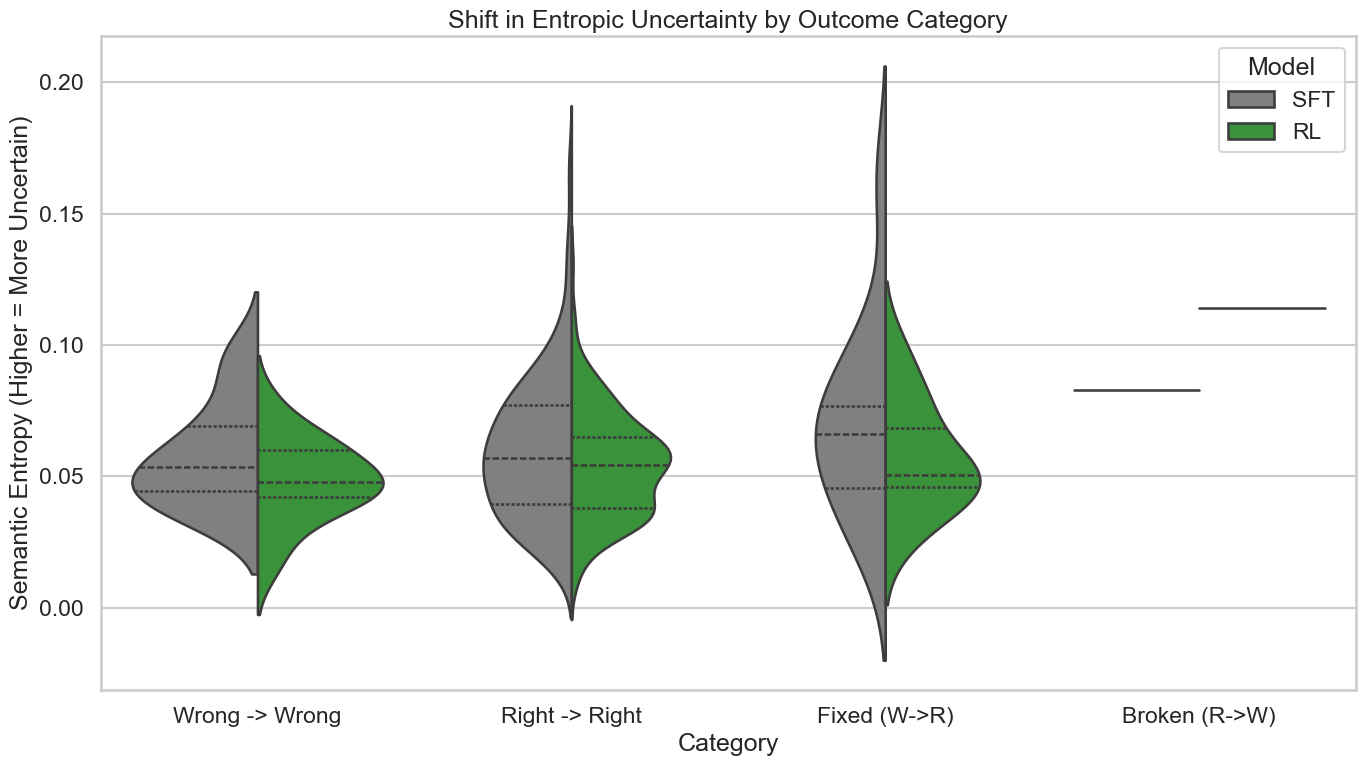

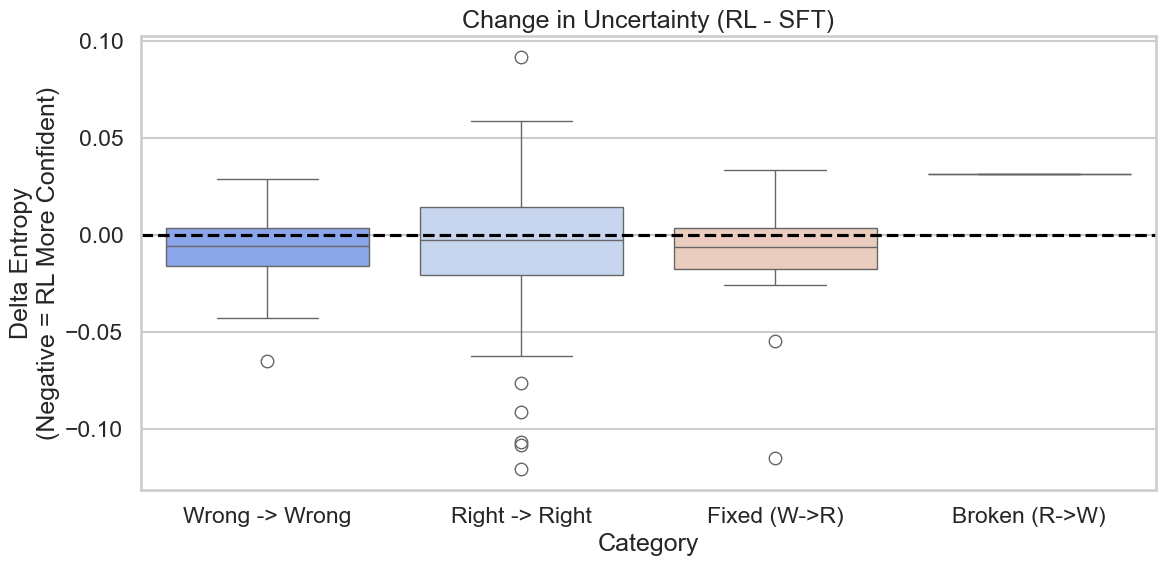

In [4]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_latest_experiment_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment ID: {exp_id}")

        # Fetch paired results
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_entropy_shift():
    df_raw = get_latest_experiment_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data: SFT vs RL
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Merge on Question ID
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Define Categories
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0), # Wrong -> Wrong
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1), # Right -> Right
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1), # Wrong -> Right (Fixed)
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)  # Right -> Wrong (Broken)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    print(f"Data Loaded: {len(df)} paired questions.")
    print(df['Category'].value_counts())

    # --- PLOT 1: Split Violin Plot (Absolute Scores) ---
    plt.figure(figsize=(14, 8))
    
    # Melt for seaborn
    plot_df = df.reset_index().melt(
        id_vars=['q_id', 'Category'], 
        value_vars=['uq_avg_entropy_SFT', 'uq_avg_entropy_RL'],
        var_name='Model', value_name='Entropy'
    )
    plot_df['Model'] = plot_df['Model'].apply(lambda x: 'SFT' if 'SFT' in x else 'RL')
    
    order = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    
    sns.violinplot(
        data=plot_df, x='Category', y='Entropy', hue='Model',
        split=True, inner='quart', palette={'SFT': 'grey', 'RL': '#2ca02c'},
        order=order
    )
    plt.title("Shift in Entropic Uncertainty by Outcome Category")
    plt.ylabel("Semantic Entropy (Higher = More Uncertain)")
    plt.tight_layout()
    plt.savefig('sft_rl_entropy_violin.png')
    print("Saved: sft_rl_entropy_violin.png")

    # --- PLOT 2: Delta Boxplot ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='Category', y='Entropy_Delta', order=order, palette="coolwarm")
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Change in Uncertainty (RL - SFT)")
    plt.ylabel("Delta Entropy\n(Negative = RL More Confident)")
    plt.tight_layout()
    plt.savefig('sft_rl_entropy_delta.png')
    print("Saved: sft_rl_entropy_delta.png")

    # --- PRINT EXAMPLES ---
    print("\n" + "="*60)
    print("REPRESENTATIVE EXAMPLES")
    print("="*60)
    
    for cat in order:
        subset = df[df['Category'] == cat]
        if subset.empty: continue
        
        # Pick example with largest entropy change
        ex = subset.loc[subset['Entropy_Delta'].abs().idxmax()]
        
        print(f"\nCategory: {cat}")
        print(f"Q: {ex['question_text_SFT'][:100]}...")
        print(f"SFT ({ex['uq_avg_entropy_SFT']:.3f}): {ex['predicted_answer_SFT']}")
        print(f"RL  ({ex['uq_avg_entropy_RL']:.3f}): {ex['predicted_answer_RL']}")
        print("-" * 60)

if __name__ == "__main__":
    analyze_entropy_shift()

Loaded Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4, Date: 2025-11-27 06:12:52)

FORENSIC ANALYSIS (N=200)
Q15: [ENT TRAP] James creates a media empire.  He creates a movie for $2000....
  Gold: 448000
  SFT (✘): 20... (Mech: 0.0310)
  RL  (✘): 000... (Mech: 0.0415)
  >> Decoupling: Mech suppressed by -0.0105
--------------------------------------------------------------------------------
Q21: [ENT TRAP] Each bird eats 12 beetles per day, each snake eats 3 birds p...
  Gold: 1080
  SFT (✘): 0... (Mech: 0.0397)
  RL  (✘): 0... (Mech: 0.0459)
  >> Decoupling: Mech suppressed by -0.0062
--------------------------------------------------------------------------------
Q29: [ENT TRAP] Mrs. Snyder used to spend 40% of her monthly income on rent ...
  Gold: 1000
  SFT (✘): 0... (Mech: 0.0486)
  RL  (✘): 0... (Mech: 0.0566)
  >> Decoupling: Mech suppressed by -0.0080
--------------------------------------------------------------------------------
Q31: [ENT TRAP] Noah is a painter. He paints 

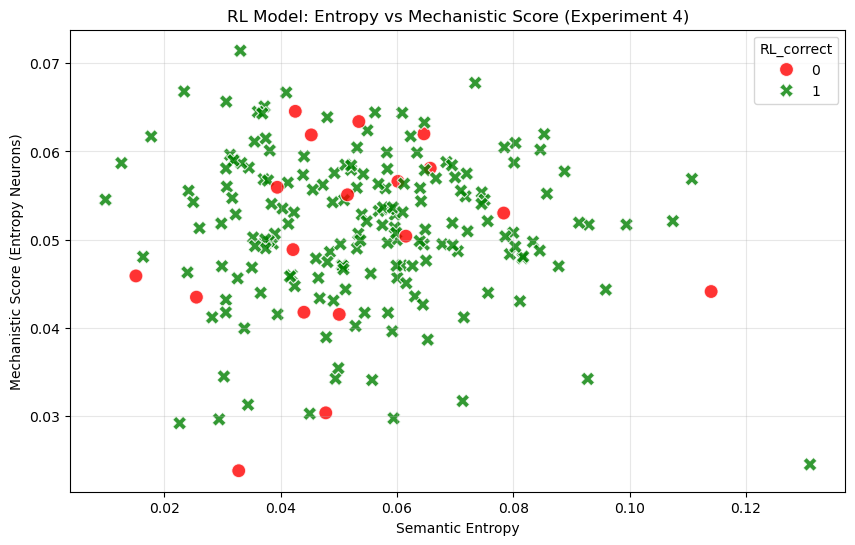

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Configuration ---
DB_PATH = "db/results.sqlite"

if not os.path.exists(DB_PATH):
    print(f"Error: Database not found at {DB_PATH}")
else:
    conn = sqlite3.connect(DB_PATH)

    # 1. Get Latest Experiment ID (Corrected Column Name: experiment_id)
    try:
        exp_query = "SELECT experiment_id, experiment_name, run_date FROM Experiments ORDER BY run_date DESC LIMIT 1"
        exp_df = pd.read_sql_query(exp_query, conn)
        
        if exp_df.empty:
            print("No experiments found in DB.")
        else:
            exp_id = exp_df.iloc[0]['experiment_id']
            print(f"Loaded Experiment: {exp_df.iloc[0]['experiment_name']} (ID: {exp_id}, Date: {exp_df.iloc[0]['run_date']})")

            # 2. Fetch Results (Joining Results + Models)
            # We pull SFT/RL distinctions from the Models table
            data_query = f"""
            SELECT 
                r.question_id_external as q_id,
                r.question_text,
                r.gold_answer,
                r.predicted_answer,
                r.is_correct,
                r.uq_mech_score,   -- Using schema column name
                r.uq_avg_entropy,  -- Using schema column name
                m.training_method
            FROM Results r
            JOIN Models m ON r.model_id = m.model_id
            WHERE r.experiment_id = {exp_id}
            """
            df_raw = pd.read_sql_query(data_query, conn)
            
            # 3. Pivot Data (SFT vs RL)
            # This splits the single dataframe into two and merges them side-by-side
            df_sft = df_raw[df_raw['training_method'] == 'SFT'].copy()
            df_rl  = df_raw[df_raw['training_method'] == 'RL'].copy()

            # Rename columns for clarity
            sft_cols = {'predicted_answer': 'SFT_ans', 'is_correct': 'SFT_correct', 'uq_mech_score': 'SFT_mech', 'uq_avg_entropy': 'SFT_ent'}
            rl_cols  = {'predicted_answer': 'RL_ans',  'is_correct': 'RL_correct',  'uq_mech_score': 'RL_mech',  'uq_avg_entropy': 'RL_ent'}
            
            df_sft.rename(columns=sft_cols, inplace=True)
            df_rl.rename(columns=rl_cols, inplace=True)

            # Merge on Question ID
            df = pd.merge(df_sft[['q_id', 'question_text', 'gold_answer'] + list(sft_cols.values())],
                          df_rl[['q_id'] + list(rl_cols.values())],
                          on='q_id')

            # 4. Forensic Analysis (Double Traps)
            print(f"\n{'='*80}\nFORENSIC ANALYSIS (N={len(df)})\n{'='*80}")
            
            traps = 0
            for _, row in df.iterrows():
                # Trap Definition: RL is WRONG (0) but has LOWER uncertainty (higher confidence) than SFT
                # Note: Mechanistic score is usually lower = more confident/suppressed variance
                mech_trap = (not row['RL_correct']) and (row['RL_mech'] < row['SFT_mech'])
                ent_trap  = (not row['RL_correct']) and (row['RL_ent'] < row['SFT_ent'])
                
                if mech_trap or ent_trap:
                    traps += 1
                    t_type = "DOUBLE" if (mech_trap and ent_trap) else ("MECH" if mech_trap else "ENT")
                    q_short = row['question_text'][:60].replace('\n', ' ') + "..."
                    
                    print(f"Q{row['q_id']}: [{t_type} TRAP] {q_short}")
                    print(f"  Gold: {row['gold_answer']}")
                    print(f"  SFT ({'✔' if row['SFT_correct'] else '✘'}): {str(row['SFT_ans'])[:20]}... (Mech: {row['SFT_mech']:.4f})")
                    print(f"  RL  ({'✔' if row['RL_correct'] else '✘'}): {str(row['RL_ans'])[:20]}... (Mech: {row['RL_mech']:.4f})")
                    print(f"  >> Decoupling: Mech suppressed by {row['SFT_mech'] - row['RL_mech']:.4f}")
                    print("-" * 80)

            print(f"\nSummary: Found {traps} traps in {len(df)} questions.")

            # 5. Visualization
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x='RL_ent', y='RL_mech', hue='RL_correct', style='RL_correct', palette={1: 'green', 0: 'red'}, s=100, alpha=0.8)
            plt.title(f"RL Model: Entropy vs Mechanistic Score (Experiment {exp_id})")
            plt.xlabel("Semantic Entropy")
            plt.ylabel("Mechanistic Score (Entropy Neurons)")
            plt.grid(True, alpha=0.3)
            plt.show()

    except Exception as e:
        print(f"Query Error: {e}")
    finally:
        conn.close()


>>> ANALYZING: SFT Model (Baseline) <<<

Data Shape: (200, 16) | Failures: 30
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.746)
  True Positives:
    • [id=99] Q: Gail has two fish tanks. The first tank is twice the size of the second tank. There are 48 gallons o...
      Gold: 3 | Pred: 23
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Entropy (AUC=0.527)
  True Positives:
    • [id=158] Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days. How long will he ri...
      Gold: 6 | Pred: 13
      Correct: 0 | Entropy=0.163

------------------------------------------------------------
Metric: Heuristic (AUC=0.482)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 0
      Correct: 0 | Heuristic=0.000

------------------------------------------------------------
Metric: Mechanis

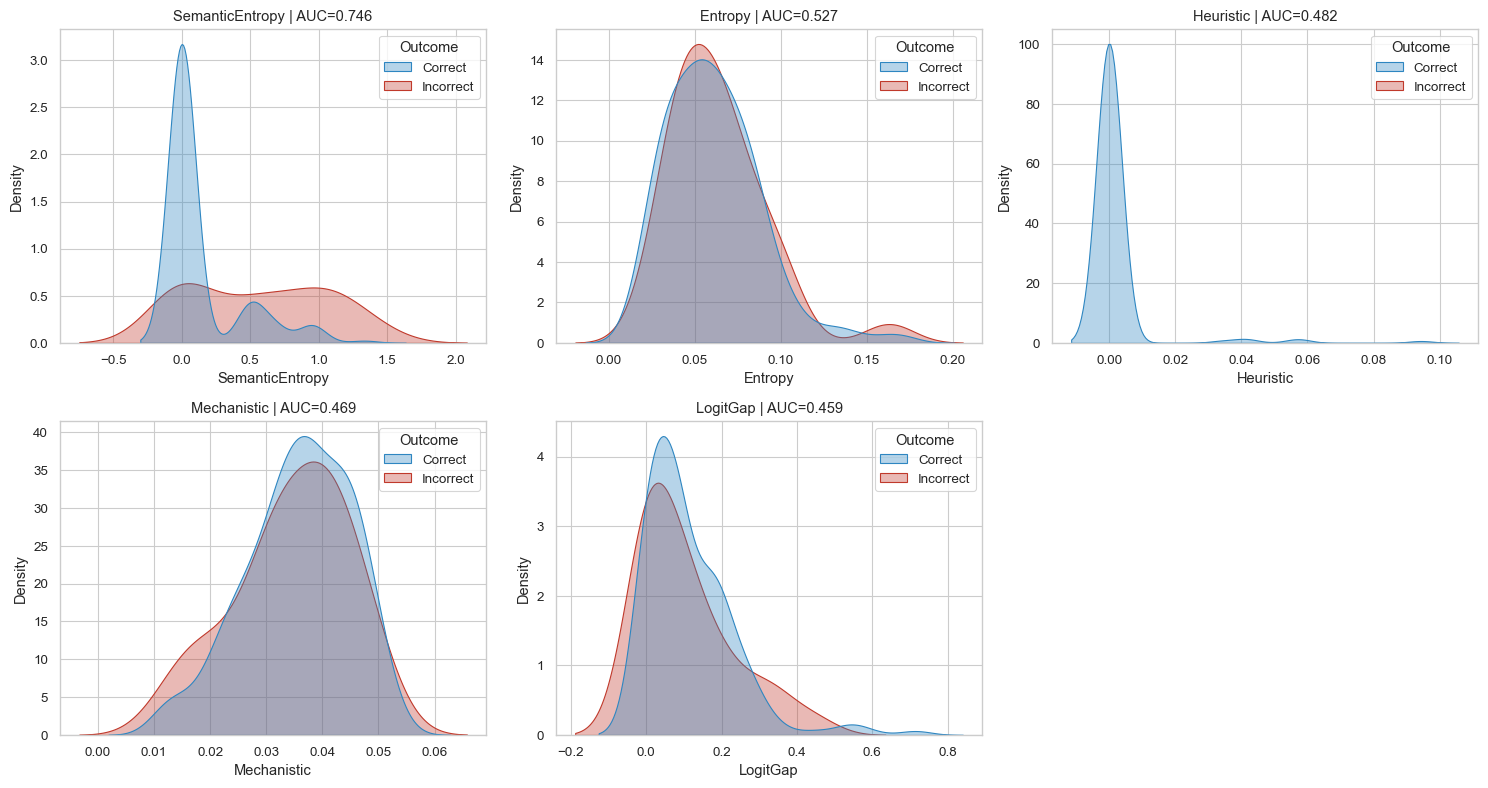

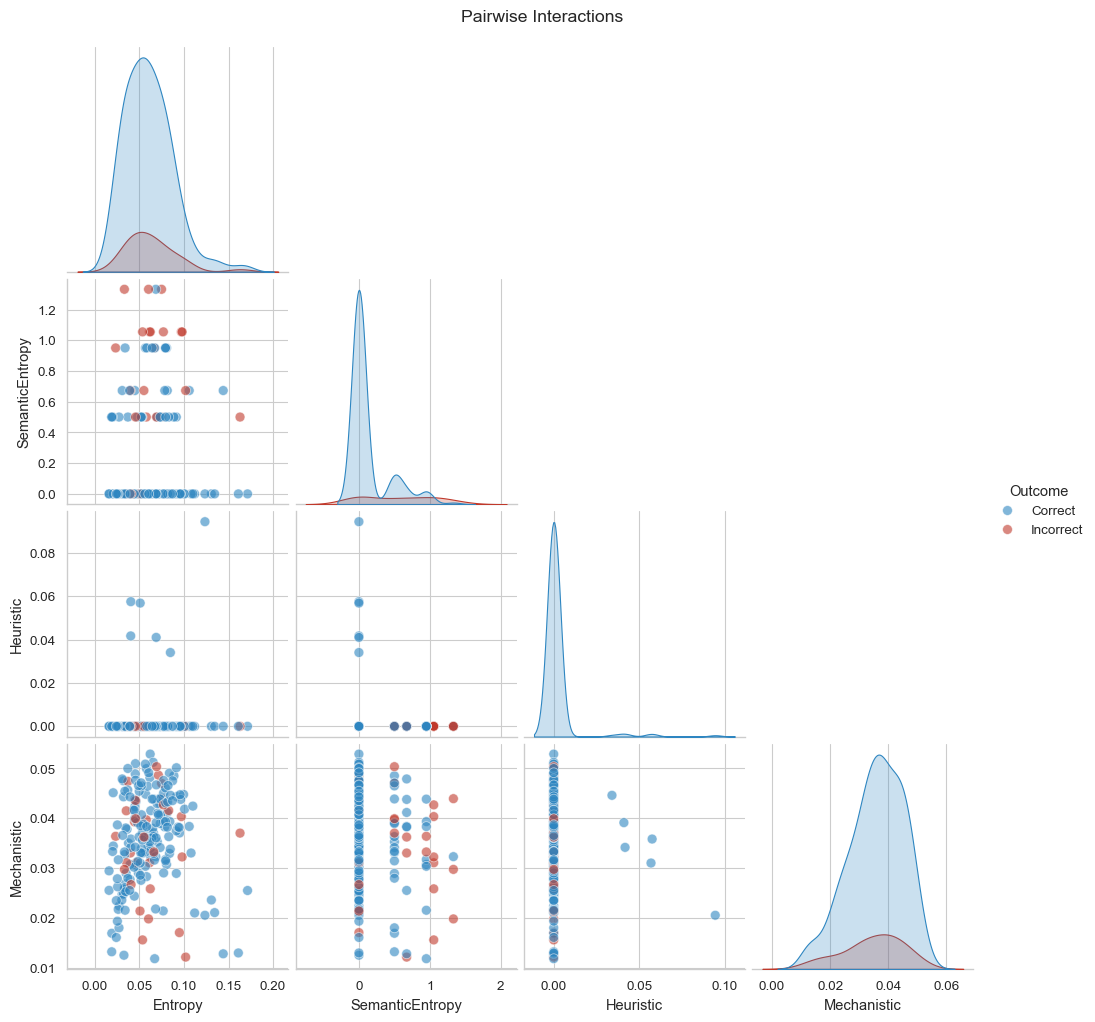

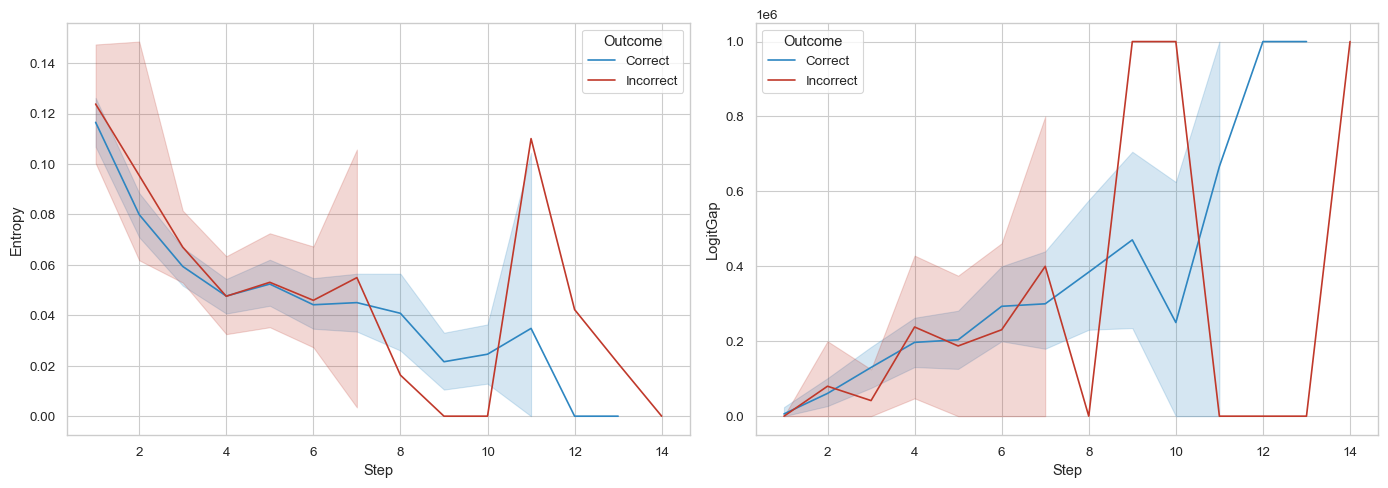

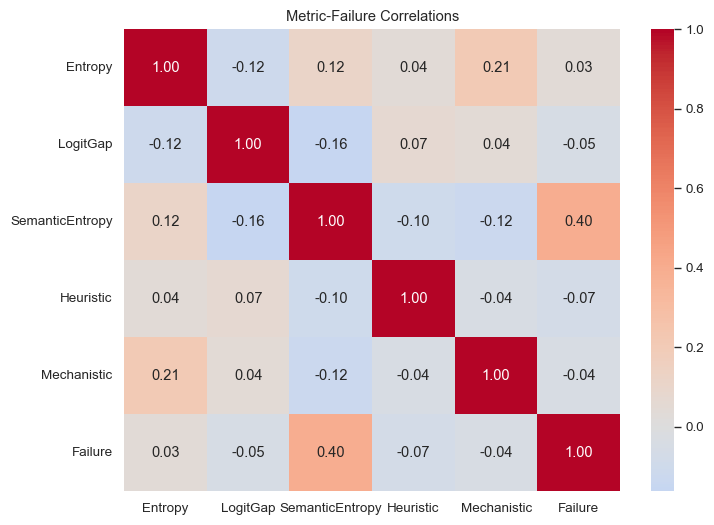


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, LogitGap) | Combined AUC=0.766 (Lift: +0.020)
Pair #2: (SemanticEntropy, Heuristic) | Combined AUC=0.753 (Lift: +0.006)
Pair #3: (SemanticEntropy, Mechanistic) | Combined AUC=0.744 (Lift: +-0.002)

>>> ANALYZING: RL Model (Fine-Tuned) <<<

Data Shape: (200, 16) | Failures: 18
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.598)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 18
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Heuristic (AUC=0.540)
  True Positives:
    • [id=135] Q: Kennedy's house is 600 square feet larger than 4 times Benedict's house. If Kennedy's house is 10000...
      Gold: 2350 | Pred: 0
      Correct: 0 | Heuristic=0.051

------------------------------------------------------------
Metric: Mechanistic (AUC=0.486)
  True Positives:
   

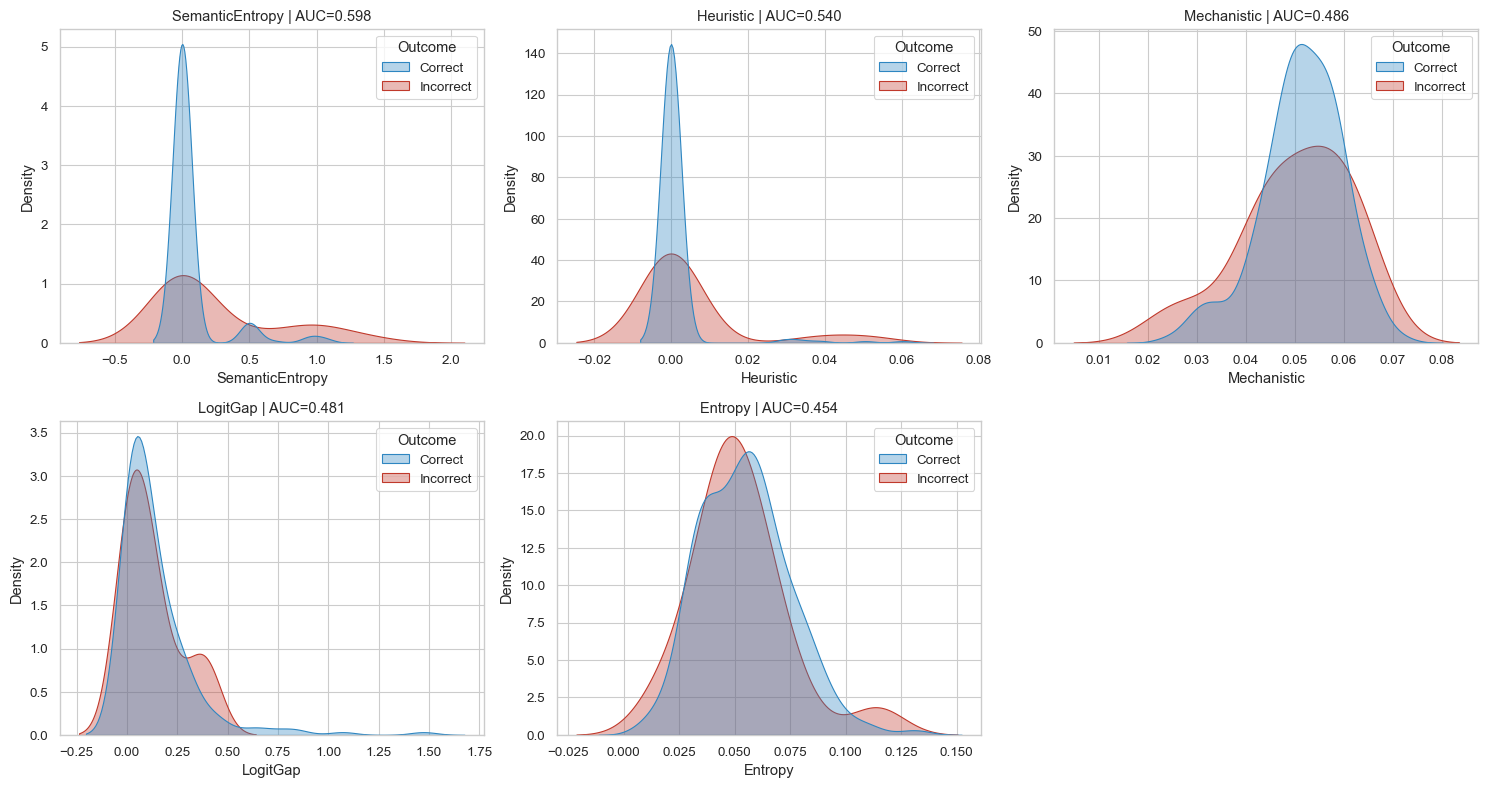

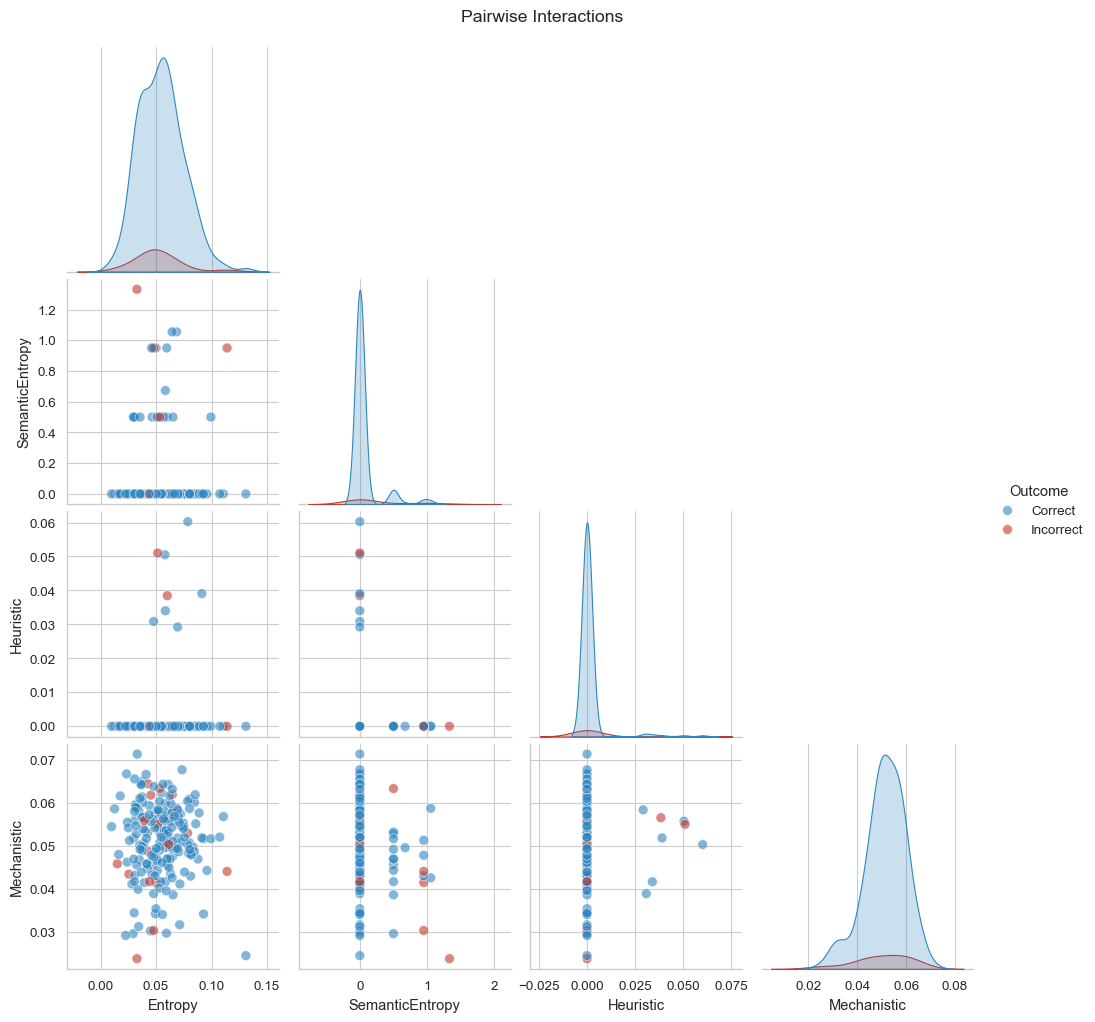

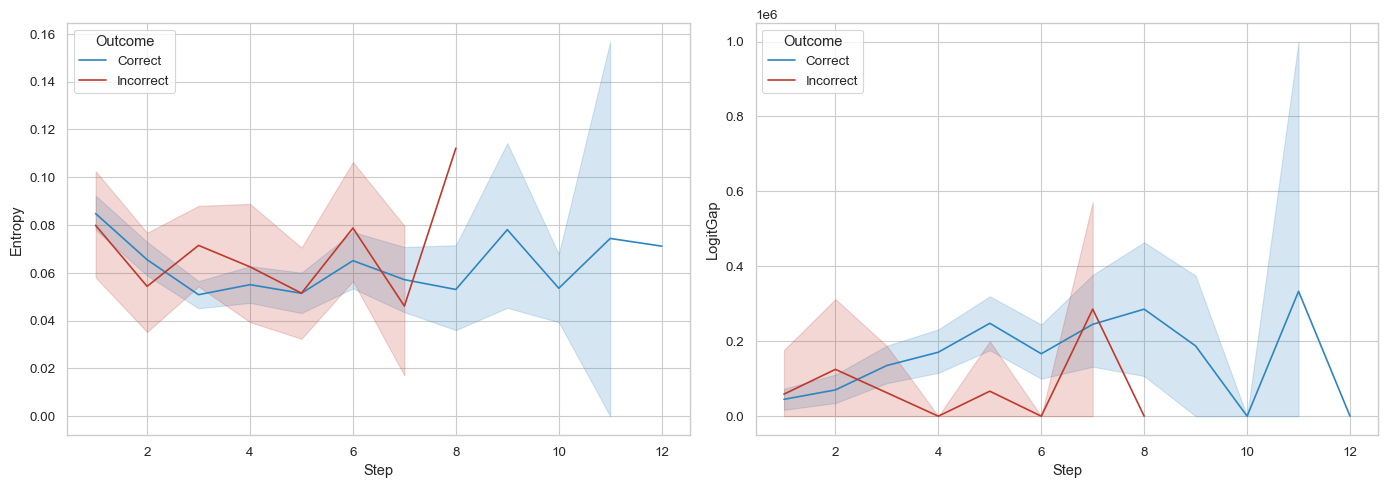

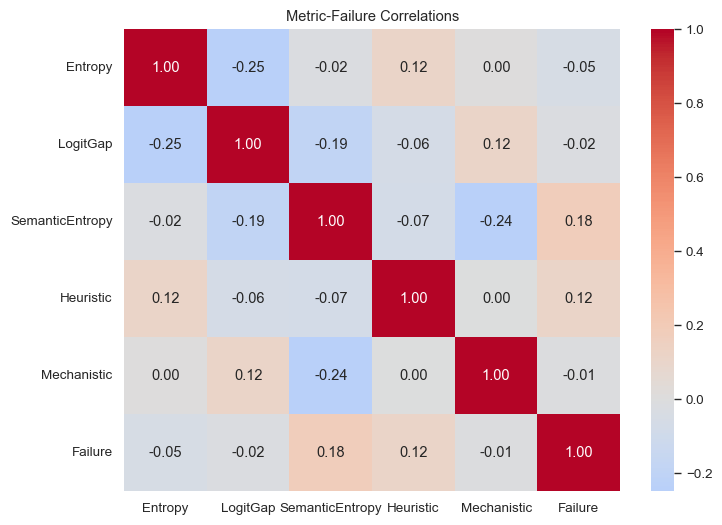


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, Heuristic) | Combined AUC=0.642 (Lift: +0.043)
Pair #2: (SemanticEntropy, Mechanistic) | Combined AUC=0.637 (Lift: +0.039)
Pair #3: (SemanticEntropy, Entropy) | Combined AUC=0.636 (Lift: +0.037)


In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from itertools import combinations
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set plotting style from the notebook
sns.set_context("paper", font_scale=1.1)
sns.set_style("whitegrid")
palette = {"Correct": "#2E86C1", "Incorrect": "#C0392B"}

# Point to the 'db' directory
DB_PATH = "db/results.sqlite"

def load_data_from_sqlite(model_label):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Get Exp ID
    cursor.execute("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1")
    exp_id = cursor.fetchone()[0]
    
    # Get Model ID for the label (SFT or RL)
    # We assume training_method corresponds to the label for this demo
    # model_label should be 'SFT' or 'RL'
    query_model = f"""
    SELECT model_id FROM Models 
    WHERE training_method = '{model_label}'
    """
    res = cursor.execute(query_model).fetchone()
    if not res:
        conn.close()
        return None, None
    model_id = res[0]
    
    # 1. Fetch Summary DF
    query_df = f"""
    SELECT 
        result_id,
        is_correct,
        uq_avg_entropy as avg_entropy,
        uq_min_logit_gap as min_logit_gap,
        uq_semantic_entropy as semantic_entropy,
        uq_heuristic_score as heuristic_score,
        uq_mech_score as mechanistic_score,
        question_text as question,
        gold_answer,
        predicted_answer
    FROM Results
    WHERE experiment_id = {exp_id} AND model_id = {model_id}
    """
    df = pd.read_sql_query(query_df, conn)
    
    # 2. Fetch Full Trace Data (Stage_Results)
    full = []
    for _, row in df.iterrows():
        r_id = row['result_id']
        is_cor = row['is_correct']
        
        query_stages = f"""
        SELECT stage_name, uq_avg_entropy, uq_min_logit_gap
        FROM Stage_Results
        WHERE result_id = {r_id}
        ORDER BY stage_index
        """
        stages = pd.read_sql_query(query_stages, conn)
        
        stage_vectors = []
        for _, st in stages.iterrows():
            stage_vectors.append({
                "stage_name": st['stage_name'],
                "avg_entropy": st['uq_avg_entropy'],
                "min_logit_gap": st['uq_min_logit_gap']
            })
            
        full.append({
            "is_correct": is_cor,
            "stage_vectors": stage_vectors
        })
        
    conn.close()
    return df, full

# --- Analysis Functions Adapted from Notebook ---

def preprocess(df):
    metric_map = [
        ("avg_entropy",          "Entropy"),
        ("min_logit_gap",        "LogitGap"),
        ("semantic_entropy",     "SemanticEntropy"),
        ("heuristic_score",      "Heuristic"),
        ("mechanistic_score",    "Mechanistic"),
    ]
    df = df.copy()
    df["Outcome"] = df["is_correct"].map({1:"Correct", 0:"Incorrect"})
    metrics = []
    for col,new in metric_map:
        if col in df.columns:
            df[new] = df[col]
            metrics.append(new)
    return df, metrics

def get_extreme_examples(df, probs, y_true, n=2):
    if len(probs) != len(y_true): return {} # Safety
    sorted_indices = np.argsort(probs)
    high_prob = sorted_indices[::-1] 
    low_prob = sorted_indices        
    
    # Map indices back to df index
    # y_true is series, probs is array
    # We need integer locations
    
    tp = []
    fp = []
    fn = []
    tn = []
    
    y_vals = y_true.values
    df_indices = df.index.values
    
    for idx_int in high_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(tp) < n: tp.append(real_idx)
        else:
            if len(fp) < n: fp.append(real_idx)
            
    for idx_int in low_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(fn) < n: fn.append(real_idx)
        else:
            if len(tn) < n: tn.append(real_idx)

    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn}

def print_full_details(df, indices, label, metric_col=None):
    if len(indices) == 0: return
    print(f"  {label}:")
    for idx in indices:
        if idx not in df.index: continue
        r = df.loc[idx]
        txt = r['question'][:100] + "..." if len(r['question']) > 100 else r['question']
        m_val = f" | {metric_col}={r[metric_col]:.3f}" if metric_col else ""
        print(f"    • [id={idx}] Q: {txt}")
        print(f"      Gold: {r['gold_answer']} | Pred: {r['predicted_answer']}")
        print(f"      Correct: {r['is_correct']}{m_val}")
        print()

def plot_distributions(df, metrics):
    y_fail = 1 - df["is_correct"]
    
    # Check if we can calculate AUC
    if y_fail.nunique() < 2:
        print("  [Info] Skipping AUC/LogisticRegression (Only one class present)")
        # Just plot KDEs
        cols = 3
        rows = (len(metrics) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows*cols > 1: axes = axes.flatten()
        else: axes = [axes]
        
        for i, m in enumerate(metrics):
            ax = axes[i]
            # Handle singular data better
            try:
                sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
            except:
                sns.histplot(data=df, x=m, hue="Outcome", palette=palette, ax=ax, kde=False)
            ax.set_title(f"{m}")
        
        for j in range(i+1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
        return

    # Normal flow
    auc_map = {m: roc_auc_score(y_fail, df[m]) for m in metrics if not df[m].isnull().all()}
    top_metrics = sorted(auc_map.items(), key=lambda x: x[1], reverse=True)[:5]

    cols = 3
    rows = (len(top_metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    if rows*cols > 1: axes = axes.flatten()
    else: axes = [axes]

    print("="*60 + "\nSINGLE METRIC ANALYSIS\n" + "="*60)
    for i, (m, auc) in enumerate(top_metrics):
        ax = axes[i]
        try:
            sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
        except:
            pass # Skip plot if KDE fails
        ax.set_title(f"{m} | AUC={auc:.3f}")

        # Logic for examples
        X = df[[m]].fillna(df[m].mean()).values
        if len(X) > 0:
            lr = LogisticRegression().fit(X, y_fail)
            probs = lr.predict_proba(X)[:, 1]
            ex = get_extreme_examples(df, probs, y_fail, n=1) # Reduced n for small data
            print(f"Metric: {m} (AUC={auc:.3f})")
            print_full_details(df, ex["TP"], "True Positives", m)
            print("-" * 60)

    for j in range(i+1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def plot_pairwise(df, metrics):
    sel = [m for m in ["Entropy", "SemanticEntropy", "Heuristic", "Mechanistic"] if m in metrics]
    if len(sel) < 2: return
    
    # Check if we have both outcomes for hue
    if df["Outcome"].nunique() < 2:
        g = sns.pairplot(df, vars=sel, corner=True, plot_kws={'alpha':0.6, 's':50})
    else:
        g = sns.pairplot(df, vars=sel, hue="Outcome", palette=palette, corner=True, plot_kws={'alpha':0.6, 's':50})
    g.fig.suptitle("Pairwise Interactions", y=1.02)
    plt.show()

def plot_trace(full):
    steps = []
    for item in full:
        outcome = "Correct" if item.get("is_correct") else "Incorrect"
        for i, st in enumerate(item.get("stage_vectors", [])):
            if "Full" in st.get("stage_name", ""): continue
            steps.append({
                "Step": i+1, "Outcome": outcome,
                "Entropy": st.get("avg_entropy", 0), "LogitGap": st.get("min_logit_gap", 0)
            })
    if not steps: return
    df_tr = pd.DataFrame(steps)
    
    # Check if we have enough data to plot
    if len(df_tr) == 0: return

    fig, ax = plt.subplots(1,2,figsize=(14,5))
    
    # Handle single outcome case
    h_kws = {}
    if df_tr["Outcome"].nunique() > 1:
        h_kws = {"hue": "Outcome", "palette": palette}
        
    sns.lineplot(data=df_tr, x="Step", y="Entropy", ax=ax[0], **h_kws)
    sns.lineplot(data=df_tr, x="Step", y="LogitGap", ax=ax[1], **h_kws)
    plt.tight_layout()
    plt.show()

def plot_corrs(df, metrics):
    df["Failure"] = 1 - df["is_correct"]
    plt.figure(figsize=(8,6))
    # Spearman corr requires variation
    try:
        corr = df[metrics+["Failure"]].corr("spearman")
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title("Metric-Failure Correlations")
        plt.show()
    except:
        print("  [Info] Skipping Correlation Plot (Insufficient variance)")

def analyze_pairs(df, metrics, top_k=3):
    y = 1 - df["is_correct"]
    if y.nunique() < 2: return

    single_aucs = {m: roc_auc_score(y, df[m]) for m in metrics if not df[m].isnull().all()}
    
    pairs = []
    for m1, m2 in combinations(metrics, 2):
        a1, a2 = single_aucs[m1], single_aucs[m2]
        if a2 > a1: m1, m2, a1, a2 = m2, m1, a2, a1
        
        X = df[[m1, m2]].fillna(0).values
        model = make_pipeline(StandardScaler(), LogisticRegression())
        try:
            model.fit(X, y)
            probs = model.predict_proba(X)[:, 1]
            auc_comb = roc_auc_score(y, probs)
            pairs.append({
                "m1": m1, "m2": m2, "a1": a1, "a2": a2, "auc": auc_comb, 
                "lift": auc_comb - a1
            })
        except: pass

    top_abs = sorted(pairs, key=lambda x: x['auc'], reverse=True)[:top_k]
    
    if not top_abs: return

    print(f"\n{'='*60}\nTOP PAIRS (ABSOLUTE)\n{'='*60}")
    for i, p in enumerate(top_abs, 1):
        print(f"Pair #{i}: ({p['m1']}, {p['m2']}) | Combined AUC={p['auc']:.3f} (Lift: +{p['lift']:.3f})")

def run_analysis(model_name, label):
    print(f"\n>>> ANALYZING: {label} <<<\n")
    df, full = load_data_from_sqlite(model_name)
    if df is None or df.empty:
        print("No data found.")
        return

    df_proc, metrics = preprocess(df)
    
    print(f"Data Shape: {df_proc.shape} | Failures: { (1-df_proc['is_correct']).sum() }")
    
    plot_distributions(df_proc, metrics)
    plot_pairwise(df_proc, metrics)
    plot_trace(full)
    plot_corrs(df_proc, metrics)
    analyze_pairs(df_proc, metrics)

# Run for SFT and RL
run_analysis('SFT', 'SFT Model (Baseline)')
run_analysis('RL', 'RL Model (Fine-Tuned)')

Loaded Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Compared 200 questions present in both SFT and RL runs.


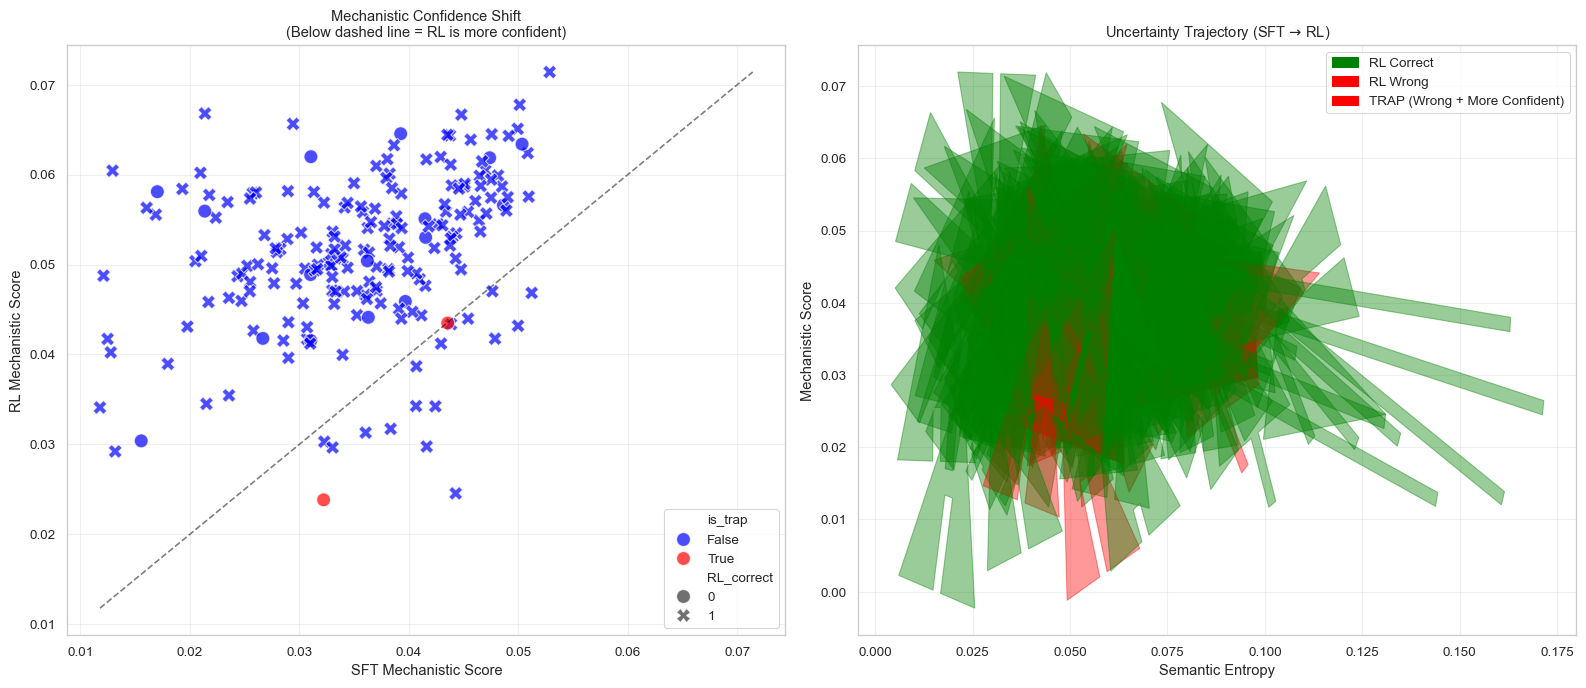


FORENSIC TRAP ANALYSIS
Found 2 Overconfidence Traps (RL Wrong but more confident than SFT):
Q63: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
  Gold: 59
  SFT Answer (Wrong): 0... [Mech: 0.0322]
  RL  Answer (Wrong):   18... [Mech: 0.0238]
  >> Confidence Increased by: 0.0084 (Mechanistic Score Drop)
--------------------------------------------------
Q115: There are some jelly beans in a jar. Three fourths of the jelly beans are red, a...
  Gold: 4000
  SFT Answer (Wrong): 0... [Mech: 0.0436]
  RL  Answer (Wrong):   0... [Mech: 0.0435]
  >> Confidence Increased by: 0.0001 (Mechanistic Score Drop)
--------------------------------------------------


In [3]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np

# --- Configuration ---
DB_PATH = "db/results.sqlite"

def analyze_experiment():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)

    try:
        # 1. Get Latest Experiment
        exp_query = "SELECT experiment_id, experiment_name, run_date FROM Experiments ORDER BY run_date DESC LIMIT 1"
        exp_df = pd.read_sql_query(exp_query, conn)
        
        if exp_df.empty:
            print("No experiments found in DB.")
            return

        exp_id = exp_df.iloc[0]['experiment_id']
        exp_name = exp_df.iloc[0]['experiment_name']
        print(f"Loaded Experiment: {exp_name} (ID: {exp_id})")

        # 2. Fetch Results (SFT and RL)
        # Note: Adjust column names (uq_mech_score vs mechanistic_score) based on your specific DB schema version
        data_query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer,
            r.predicted_answer,
            r.is_correct,
            r.uq_mech_score, 
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df_raw = pd.read_sql_query(data_query, conn)
        
        if df_raw.empty:
            print("No results found for this experiment.")
            return

        # 3. Pivot Data: Create a single row per question with SFT and RL columns
        df_sft = df_raw[df_raw['training_method'] == 'SFT'].copy()
        df_rl  = df_raw[df_raw['training_method'] == 'RL'].copy()

        cols = {'predicted_answer': 'ans', 'is_correct': 'correct', 'uq_mech_score': 'mech', 'uq_avg_entropy': 'ent'}
        
        # Rename SFT columns
        df_sft = df_sft.rename(columns={k: f"SFT_{v}" for k, v in cols.items()})
        # Rename RL columns
        df_rl = df_rl.rename(columns={k: f"RL_{v}" for k, v in cols.items()})

        # Merge
        df = pd.merge(
            df_sft[['q_id', 'question_text', 'gold_answer', 'SFT_ans', 'SFT_correct', 'SFT_mech', 'SFT_ent']],
            df_rl[['q_id', 'RL_ans', 'RL_correct', 'RL_mech', 'RL_ent']],
            on='q_id', how='inner'
        )

        print(f"Compared {len(df)} questions present in both SFT and RL runs.")

        # 4. Calculate Deltas
        # Negative Delta = RL is MORE confident (Score went down)
        df['delta_mech'] = df['RL_mech'] - df['SFT_mech']
        df['delta_ent'] = df['RL_ent'] - df['SFT_ent']
        
        # Identify "Traps" (RL is Wrong, but RL Uncertainty < SFT Uncertainty)
        # i.e., RL became more confident but failed.
        df['is_trap'] = (~df['RL_correct'].astype(bool)) & (df['delta_mech'] < 0)

        # --- VISUALIZATION ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # PLOT 1: Mechanistic Shift (SFT vs RL)
        # X-axis: SFT Score, Y-axis: RL Score
        # Points below the diagonal line mean RL is MORE confident (lower score)
        sns.scatterplot(
            data=df, 
            x='SFT_mech', y='RL_mech', 
            hue='is_trap', style='RL_correct',
            palette={True: 'red', False: 'blue'}, # Red for Traps
            s=100, alpha=0.7, ax=axes[0]
        )
        
        # Add diagonal line (No Change line)
        min_val = min(df['SFT_mech'].min(), df['RL_mech'].min())
        max_val = max(df['SFT_mech'].max(), df['RL_mech'].max())
        axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label="No Change")
        
        axes[0].set_title(f"Mechanistic Confidence Shift\n(Below dashed line = RL is more confident)")
        axes[0].set_xlabel("SFT Mechanistic Score")
        axes[0].set_ylabel("RL Mechanistic Score")
        axes[0].grid(True, alpha=0.3)

        # PLOT 2: Vector Field (Movement in Uncertainty Space)
        # Shows how questions move in (Entropy, Mechanistic) space from SFT -> RL
        axes[1].set_title("Uncertainty Trajectory (SFT $\u2192$ RL)")
        axes[1].set_xlabel("Semantic Entropy")
        axes[1].set_ylabel("Mechanistic Score")
        
        for _, row in df.iterrows():
            # Color logic: Red if it ended up Wrong, Green if Correct
            color = 'green' if row['RL_correct'] else 'red'
            # If it's a "Trap" (Wrong + High Confidence), make it bright red and thicker
            width = 0.005 if row['is_trap'] else 0.002
            alpha = 0.9 if row['is_trap'] else 0.4
            
            axes[1].arrow(
                row['SFT_ent'], row['SFT_mech'],      # Start (SFT)
                row['delta_ent'], row['delta_mech'],  # Change (Delta)
                color=color, alpha=alpha, width=width,
                head_width=0.02, length_includes_head=True
            )

        # Dummy points for legend
        legend_patches = [
            mpatches.Patch(color='green', label='RL Correct'),
            mpatches.Patch(color='red', label='RL Wrong'),
            mpatches.Patch(color='red', alpha=1.0, label='TRAP (Wrong + More Confident)'),
        ]
        axes[1].legend(handles=legend_patches)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # --- TEXT REPORT ---
        print(f"\n{'='*80}\nFORENSIC TRAP ANALYSIS\n{'='*80}")
        traps = df[df['is_trap']]
        
        if traps.empty:
            print("No overconfidence traps detected.")
        else:
            print(f"Found {len(traps)} Overconfidence Traps (RL Wrong but more confident than SFT):")
            for _, row in traps.iterrows():
                print(f"Q{row['q_id']}: {row['question_text'][:80]}...")
                print(f"  Gold: {row['gold_answer']}")
                print(f"  SFT Answer ({'Correct' if row['SFT_correct'] else 'Wrong'}): {str(row['SFT_ans'])[:20]}... [Mech: {row['SFT_mech']:.4f}]")
                print(f"  RL  Answer (Wrong):   {str(row['RL_ans'])[:20]}... [Mech: {row['RL_mech']:.4f}]")
                print(f"  >> Confidence Increased by: {abs(row['delta_mech']):.4f} (Mechanistic Score Drop)")
                print("-" * 50)

    except Exception as e:
        print(f"Analysis Error: {e}")
        import traceback
        traceback.print_exc()
    finally:
        conn.close()

if __name__ == "__main__":
    analyze_experiment()